In [17]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Limpieza/data/df_unificado_limpio_con_proyecciones_limpio.csv')

In [3]:
df.columns

Index(['AÑO', 'TRIMESTRE', 'PROVEEDOR', 'CÓDIGO DANE', 'DEPARTAMENTO',
       'CÓDIGO DANE.1', 'MUNICIPIO', 'SEGMENTO', 'TECNOLOGÍA',
       'VELOCIDAD BAJADA', 'VELOCIDAD SUBIDA', 'No. ACCESOS FIJOS A INTERNET',
       'Latitud', 'Longitud'],
      dtype='object')

In [4]:
municipios_unicos = df['MUNICIPIO'].unique()

In [5]:
municipios_unicos

array(['AMALFI', 'BELLO', 'CALARCA', 'FILANDIA', 'LA TEBAIDA',
       'MONTENEGRO', 'CAICEDONIA', 'TUNJA', 'PITALITO', 'CARTAGENA',
       'VILLA DE LEYVA', 'BARRANCABERMEJA', 'FALAN', 'ARACATACA', 'PAIPA',
       'LA JAGUA DE IBIRICO', 'YOPAL', 'NILO', 'MESETAS',
       'PAZ DE ARIPORO', 'EL PASO', 'SANTA MARTA', 'YUMBO', 'ANAPOIMA',
       'CIMITARRA', 'TURBO', 'SAN GIL', 'SOCORRO', 'BOSCONIA', 'ARANZAZU',
       'PEREIRA', 'PORE', 'TAME', 'CAÑASGORDAS', 'CAREPA', 'CAUCASIA',
       'EL BAGRE', 'GUARNE', 'ITAGUI', 'ITUANGO', 'LA CEJA', 'LA PINTADA',
       'REMEDIOS', 'SABANETA', 'SAN RAFAEL', 'YARUMAL', 'ARAUCA',
       'BARANOA', 'BARRANQUILLA', 'GALAPA', 'MALAMBO', 'SABANAGRANDE',
       'CANTAGALLO', 'TURBACO', 'DUITAMA', 'GARAGOA', 'SOGAMOSO', 'TUTA',
       'MANIZALES', 'NEIRA', 'AGUAZUL', 'MONTERREY', 'TAURAMENA',
       'TRINIDAD', 'CALOTO', 'MIRANDA', 'PUERTO TEJADA',
       'SANTANDER DE QUILICHAO', 'AGUACHICA', 'BECERRIL', 'LA GLORIA',
       'VALLEDUPAR', 'ISTMINA', 'LORI

In [6]:
numero_municipios = df['MUNICIPIO'].value_counts()

In [7]:
# Contar valores únicos en la columna MUNICIPIO
n_municipios = df['MUNICIPIO'].nunique()

In [8]:
n_municipios

195

In [9]:
# 1. Crear nueva columna TRIMESTRE
df['TRIMESTRE'] = ((df['AÑO'] - 2021) * 4 + df['TRIMESTRE'])

In [10]:
# 2. Concatenar DEPARTAMENTO y MUNICIPIO con un punto
df['UBICACION'] = df['DEPARTAMENTO'] + '.' + df['MUNICIPIO']

In [11]:
# 3. Seleccionar solo las columnas que necesitamos
df_final = df[[
    'TRIMESTRE',
    'UBICACION',
    'VELOCIDAD BAJADA',
    'VELOCIDAD SUBIDA',
    'No. ACCESOS FIJOS A INTERNET'
]].copy()

In [12]:
# Para verificar el resultado
print("Muestra de valores únicos en TRIMESTRE:")
print(df['TRIMESTRE'].unique())

Muestra de valores únicos en TRIMESTRE:
[ 3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13.]


In [13]:
print("\nPrimeras filas del dataset transformado:")
print(df_final.head())


Primeras filas del dataset transformado:
   TRIMESTRE         UBICACION  VELOCIDAD BAJADA  VELOCIDAD SUBIDA  \
0        3.0  ANTIOQUIA.AMALFI              20.0               5.0   
1        3.0  ANTIOQUIA.AMALFI              30.0               5.0   
2        3.0  ANTIOQUIA.AMALFI              18.0               5.0   
3        3.0   ANTIOQUIA.BELLO              30.0               5.0   
4        3.0   ANTIOQUIA.BELLO               8.0               4.0   

   No. ACCESOS FIJOS A INTERNET  
0                             1  
1                             1  
2                             1  
3                             3  
4                            10  


In [14]:
# Exportar a CSV
#df_final.to_csv('dataset_prediccion.csv', index=False)

In [15]:
# Obtener lista de ubicaciones únicas
ubicaciones = df_final['UBICACION'].unique()

In [16]:
# Para cada ubicación, crear y guardar su subdataset
for ubicacion in ubicaciones:
    # Filtrar el dataframe para esta ubicación
    df_ubicacion = df_final[df_final['UBICACION'] == ubicacion]

    # Seleccionar solo las columnas necesarias
    df_ubicacion = df_ubicacion[[
        'TRIMESTRE',
        'VELOCIDAD BAJADA',
        'VELOCIDAD SUBIDA',
        'No. ACCESOS FIJOS A INTERNET'
    ]]

    # Crear nombre de archivo (reemplazando caracteres problemáticos)
    nombre_archivo = ubicacion.replace('/', '_').replace('\\', '_')
    ruta_archivo = f'Limpieza/data/subdatasets/{nombre_archivo}.csv'

    # Guardar el archivo
    df_ubicacion.to_csv(ruta_archivo, index=False)

print(f"Se han creado {len(ubicaciones)} archivos en Limpieza/data/subdatasets/")

Se han creado 195 archivos en Limpieza/data/subdatasets/


In [18]:
# Leer un dataset específico de la carpeta de subdatasets
nombre_municipio = 'ANTIOQUIA.AMALFI'  # Ejemplo, cámbialo por el que quieras ver
ruta_archivo = f'Limpieza/data/subdatasets/{nombre_municipio}.csv'
df_municipio = pd.read_csv(ruta_archivo)

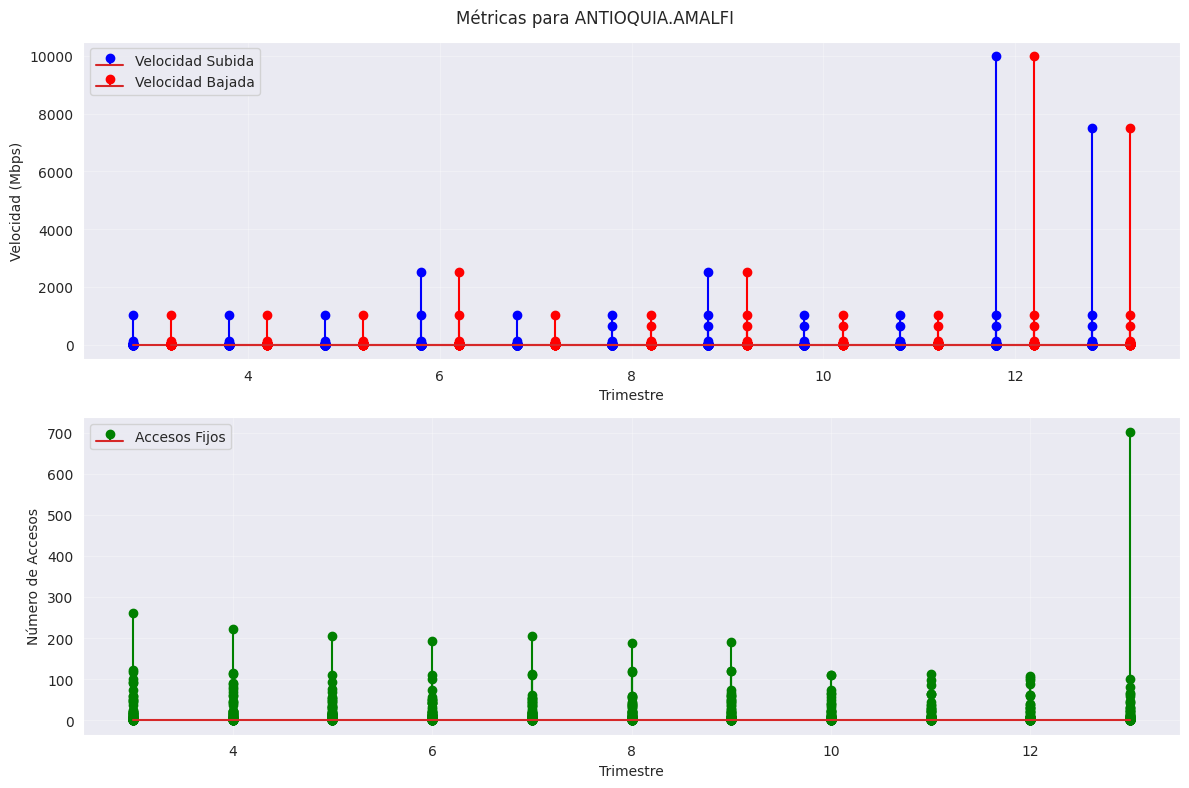

In [23]:

# Crear figura y ejes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Agregar un pequeño offset para separar las velocidades
offset = 0.2

# Graficar velocidades en el primer eje
markerline1, stemlines1, baseline1 = ax1.stem(df_municipio['TRIMESTRE'] - offset,
                                              df_municipio['VELOCIDAD SUBIDA'],
                                              label='Velocidad Subida',
                                              linefmt='b-',
                                              markerfmt='bo')
markerline2, stemlines2, baseline2 = ax1.stem(df_municipio['TRIMESTRE'] + offset,
                                              df_municipio['VELOCIDAD BAJADA'],
                                              label='Velocidad Bajada',
                                              linefmt='r-',
                                              markerfmt='ro')

# Graficar accesos en el segundo eje
markerline3, stemlines3, baseline3 = ax2.stem(df_municipio['TRIMESTRE'],
                                              df_municipio['No. ACCESOS FIJOS A INTERNET'],
                                              label='Accesos Fijos',
                                              linefmt='g-',
                                              markerfmt='go')

# Configurar etiquetas y título
ax1.set_xlabel('Trimestre')
ax1.set_ylabel('Velocidad (Mbps)')
ax2.set_xlabel('Trimestre')
ax2.set_ylabel('Número de Accesos')
fig.suptitle(f'Métricas para {nombre_municipio}')

# Agregar leyendas
ax1.legend(loc='upper left')
ax2.legend(loc='upper left')

# Ajustar diseño y estilo
plt.style.use('dark_background')
ax1.grid(True, alpha=0.3)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()